# PointNet++ Part Segmentation Demo

This notebook:
- loads a trained checkpoint
- runs the model on the full test set and prints evaluation metrics
- picks one test sample from each ShapeNet Part category
- feed those 16 samples into the model
- visualizes the prediction vs ground truth using the repo's existing visualization code


In [ ]:
import sys
from pathlib import Path
import torch

# Add the project root to Python path so notebook imports from src/ work
REPO_ROOT = Path.cwd().parent.resolve()

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Repo root:", REPO_ROOT)

Repo root: /Users/naghamsabbour/Documents/UofT/Courses/ECE1508/Project/3d-point-cloud-segmentation


In [35]:
# Import dataset, model, metrics, and visualization utilities from the repo
from src.config import DATA_ROOT, NUM_POINTS, BATCH_SIZE, USE_NORMALS
from src.dataset import ShapeNetPartDataset, load_category_mapping, load_splits
from src.pointnetpp.part_segmentation import PointNetPPPartSeg
from src.utils.partseg_metrics import evaluate_partseg, SEG_CLASSES
from src.utils.utils import choose_device, set_seed
from src.visualize import visualize_part_seg_comparison

In [36]:
# Set the checkpoint path and choose the device to run on
set_seed()
device = choose_device()
CHECKPOINT_PATH = REPO_ROOT / "checkpoints/pointnetpp-part-segmentation-with-multiscale-2026-04-08-22-35.pt"
DATA_ROOT_PATH = REPO_ROOT / Path(DATA_ROOT)

print("Device:", device)
print("Default data root:", DATA_ROOT_PATH)
print("Checkpoint path:", CHECKPOINT_PATH)

2026-04-10-18:17 - utils - INFO - Chosen device: mps


Device: mps
Default data root: /Users/naghamsabbour/Documents/UofT/Courses/ECE1508/Project/3d-point-cloud-segmentation/data/shapenetcore_partanno_segmentation_benchmark_v0_normal
Checkpoint path: /Users/naghamsabbour/Documents/UofT/Courses/ECE1508/Project/3d-point-cloud-segmentation/checkpoints/pointnetpp-part-segmentation-with-multiscale-2026-04-08-22-35.pt


## Load checkpoint, dataset, and model

In [37]:
# Check that the checkpoint and dataset path exist
assert CHECKPOINT_PATH.exists(), f"Checkpoint not found: {CHECKPOINT_PATH}"
assert DATA_ROOT_PATH.exists(), f"Dataset root not found: {DATA_ROOT_PATH}"

# Load the trained model checkpoint
ckpt = torch.load(CHECKPOINT_PATH, map_location=device)

# Recover the saved model settings
use_normals = bool(ckpt.get("use_normals", USE_NORMALS))
in_channels = int(ckpt["in_channels"])
num_part_classes = int(ckpt["num_part_classes"])
use_category_conditioning = bool(ckpt.get("use_category_conditioning", False))
num_categories = int(ckpt.get("num_categories", len(SEG_CLASSES)))
category_embed_dim = int(ckpt.get("category_embed_dim", 0))
sa_aggregation = ckpt.get("sa_aggregation", "multiscale")

category_mapping = load_category_mapping(str(DATA_ROOT_PATH))
_, _, test_list = load_splits(str(DATA_ROOT_PATH))

In [38]:
# Load the test dataset and dataloader
test_dataset = ShapeNetPartDataset(
    data_root=str(DATA_ROOT_PATH),
    split_list=test_list,
    category_mapping=category_mapping,
    num_points=NUM_POINTS,
    use_normals=use_normals,
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

In [39]:
# Hardcoded architecture settings for this trained checkpoint
extra_kwargs = {
    "sa1_npoint": 512,
    "sa1_msg_radii": [0.1, 0.2, 0.4],
    "sa1_msg_max_neighbors": [32, 64, 128],
    "sa1_msg_mlp_dims_per_scale": [[32, 32, 64], [64, 64, 128], [64, 96, 128]],
    "sa2_npoint": 128,
    "sa2_msg_radii": [0.4, 0.8],
    "sa2_msg_max_neighbors": [64, 128],
    "sa2_msg_mlp_dims_per_scale": [[128, 128, 256], [128, 196, 256]],
    "fp1_mlp_dims": [128, 128],
    "fp2_mlp_dims": [128, 128],
    "head_mlp_dims": [128, 64],
}

In [40]:
# Build the model using the same architecture settings recovered from the checkpoint
model = PointNetPPPartSeg(
    in_channels=in_channels,
    num_part_classes=num_part_classes,
    num_categories=(num_categories if use_category_conditioning else None),
    category_embed_dim=(category_embed_dim if use_category_conditioning else 0),
    sa_aggregation=sa_aggregation,
    **extra_kwargs,
).to(device)

# Load the trained weights
model.load_state_dict(ckpt["model_state_dict"], strict=True)
model.eval()

# Map class indices back to category names
class_idx_to_cat = test_dataset.idx_to_category

print("Loaded checkpoint:", CHECKPOINT_PATH.name)
print("Set abstraction grouping:", sa_aggregation)
print("Use normals:", use_normals)
print("Use category conditioning:", use_category_conditioning)
print("Test set size:", len(test_dataset))

Loaded checkpoint: pointnetpp-part-segmentation-with-multiscale-2026-04-08-22-35.pt
Set abstraction grouping: multiscale
Use normals: False
Use category conditioning: False
Test set size: 2874


## Run evaluation on test set

In [41]:
# Run evaluation function on the full test dataset
metrics = evaluate_partseg(
    model=model,
    loader=test_loader,
    device=device,
    class_idx_to_cat=class_idx_to_cat,
    cat_to_parts=SEG_CLASSES,
    loss_fn=None,
    use_category_conditioning=use_category_conditioning,
    save_visualizations=False,
)

print("Overall test metrics")
print("-" * 40)
print(f"Accuracy:            {metrics['accuracy']:.5f}")
print(f"Class avg accuracy:  {metrics['class_avg_accuracy']:.5f}")
print(f"Class avg mIoU:      {metrics['class_avg_miou']:.5f}")
print(f"Instance avg mIoU:   {metrics['instance_avg_miou']:.5f}")

print("\nPer-category mIoU")
print("-" * 40)
for cat, miou in metrics["per_category_miou"].items():
    print(f"{cat:<15} {miou:.6f}")

Overall test metrics
----------------------------------------
Accuracy:            0.89417
Class avg accuracy:  0.70709
Class avg mIoU:      0.69685
Instance avg mIoU:   0.78690

Per-category mIoU
----------------------------------------
Airplane        0.757235
Bag             0.588151
Cap             0.626143
Car             0.691341
Chair           0.873538
Earphone        0.595587
Guitar          0.874628
Knife           0.779025
Lamp            0.771276
Laptop          0.915839
Motorbike       0.322698
Mug             0.863559
Pistol          0.698268
Rocket          0.329838
Skateboard      0.693350
Table           0.769148


## Select one test sample from every class

In [42]:
# Store one test example from each object category
one_sample_per_class = {}
one_index_per_class = {}

for idx in range(len(test_dataset)):
    _, class_label, _ = test_dataset[idx]
    class_idx = int(class_label.item())
    class_name = class_idx_to_cat[class_idx]

    if class_name not in one_sample_per_class:
        one_sample_per_class[class_name] = test_dataset[idx]
        one_index_per_class[class_name] = idx

    if len(one_sample_per_class) == len(class_idx_to_cat):
        break

print(f"Collected {len(one_sample_per_class)} samples.")
for class_name in sorted(one_sample_per_class.keys()):
    print(f"{class_name:<15} dataset index = {one_index_per_class[class_name]}")

Collected 16 samples.
Airplane        dataset index = 2
Bag             dataset index = 283
Cap             dataset index = 451
Car             dataset index = 36
Chair           dataset index = 0
Earphone        dataset index = 171
Guitar          dataset index = 56
Knife           dataset index = 37
Lamp            dataset index = 9
Laptop          dataset index = 116
Motorbike       dataset index = 163
Mug             dataset index = 91
Pistol          dataset index = 15
Rocket          dataset index = 44
Skateboard      dataset index = 42
Table           dataset index = 1


## Run inference and visualize Prediction vs Ground Truth for each class

This uses the repo's existing `visualize_part_seg_comparison()` function.


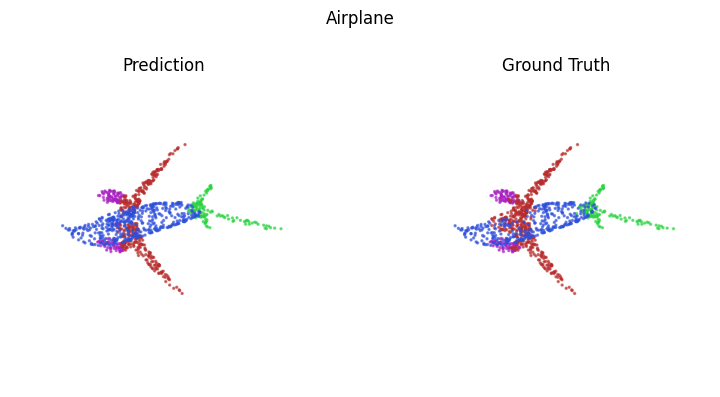

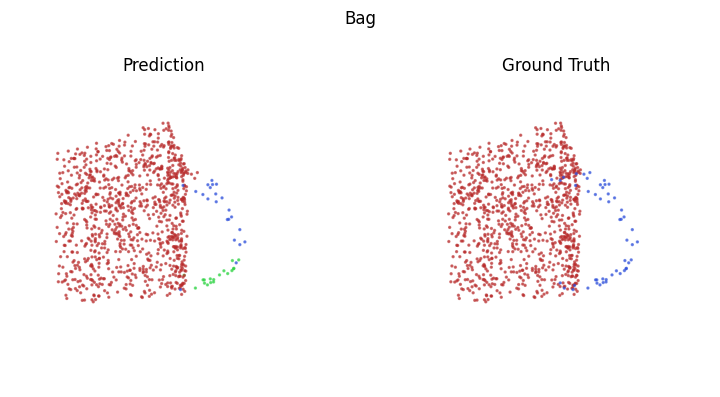

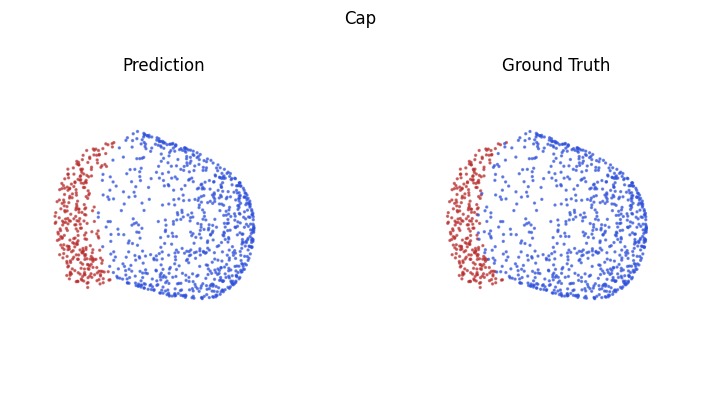

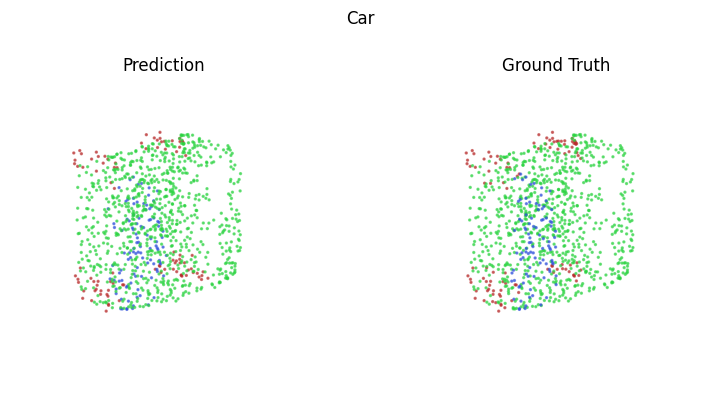

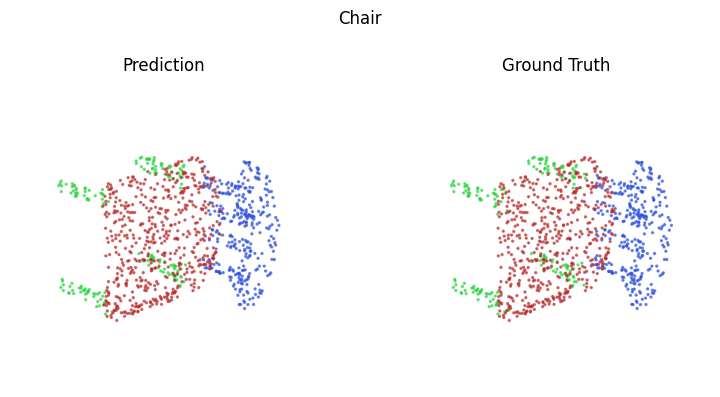

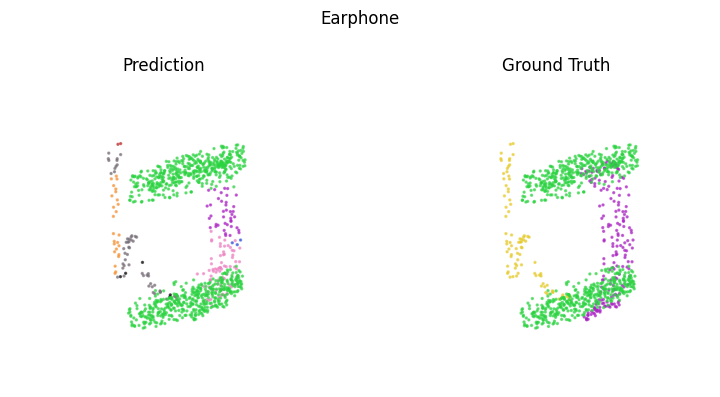

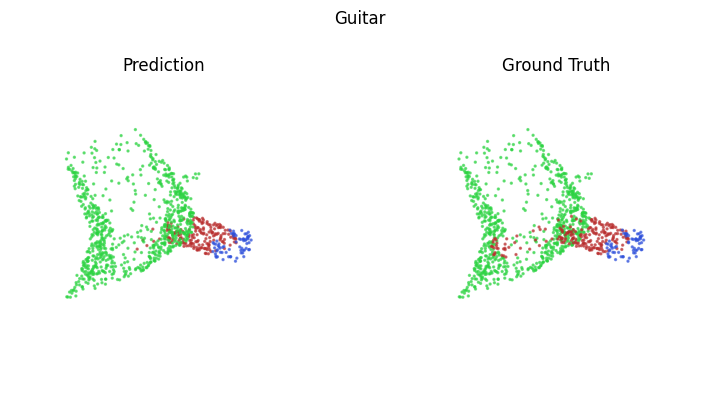

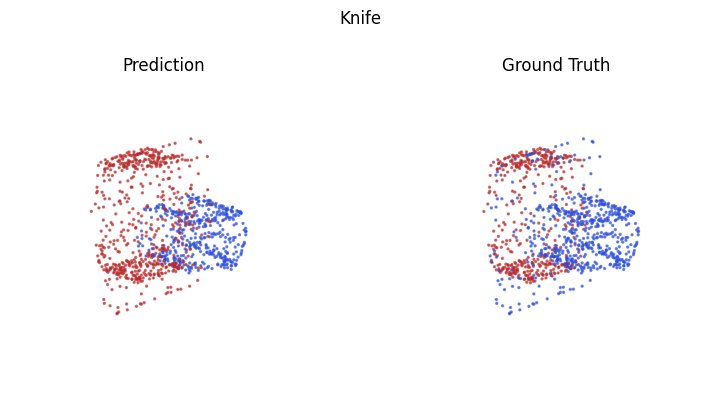

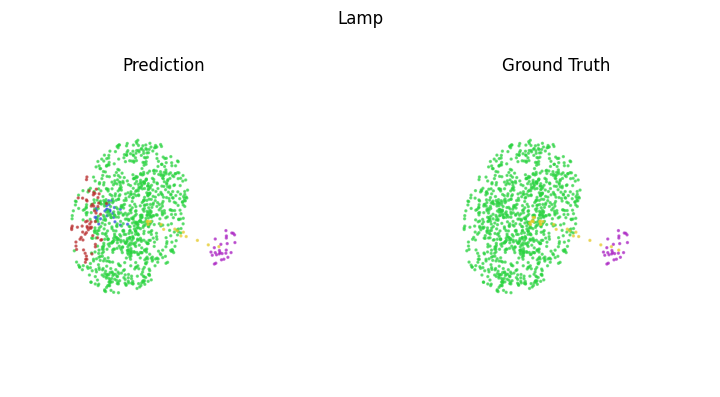

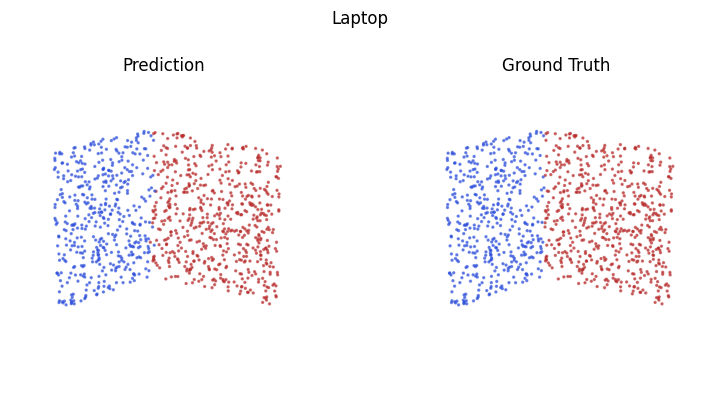

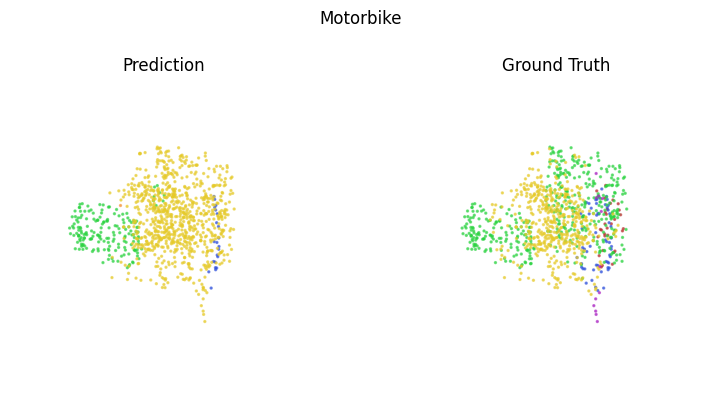

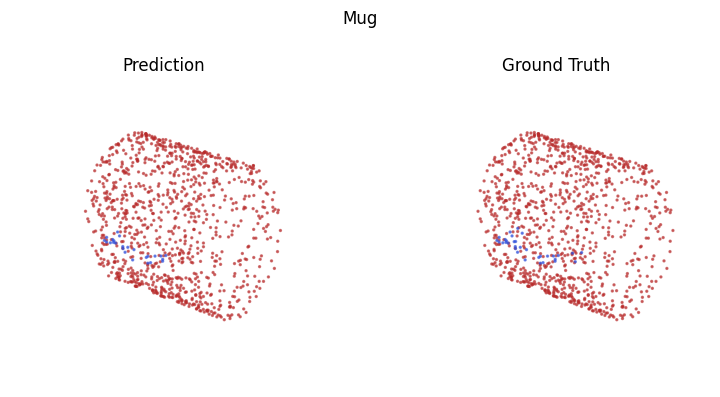

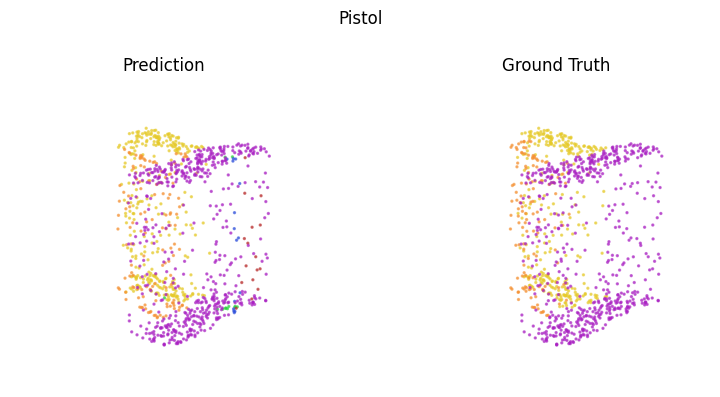

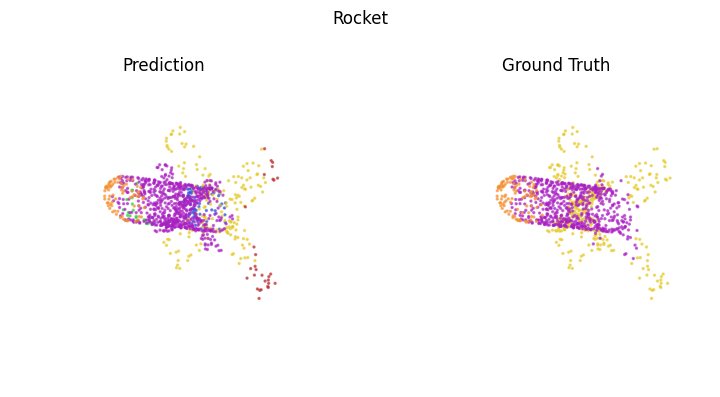

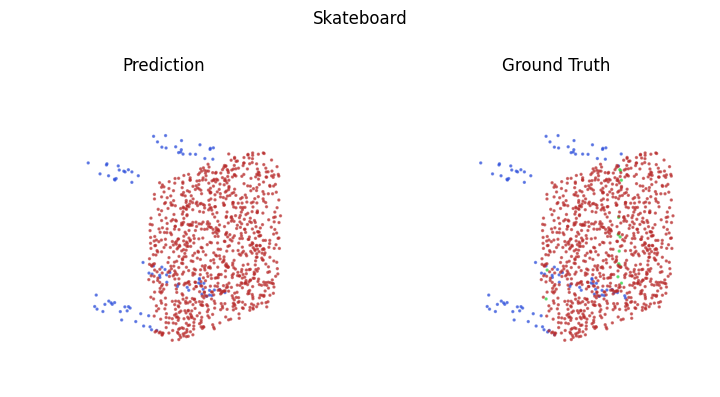

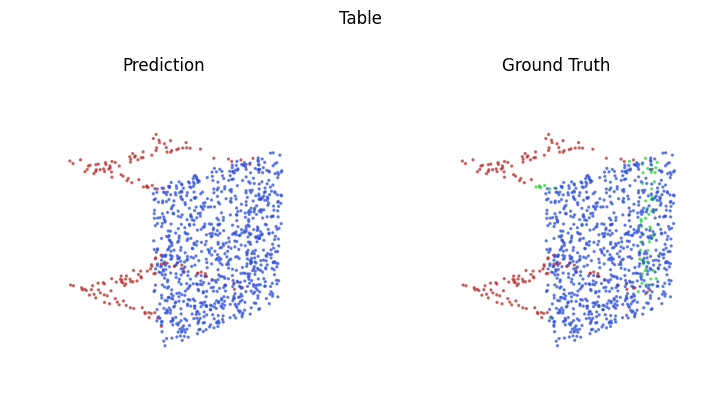

In [43]:
# Run the model on one sample and get predicted part labels
def predict_sample(points_tensor, class_label_tensor):
    points_batch = points_tensor.unsqueeze(0).to(device)
    class_batch = class_label_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(points_batch, class_batch) if use_category_conditioning else model(points_batch)
        pred = logits.argmax(dim=-1).squeeze(0).cpu().numpy()

    return pred

# Visualize prediction vs ground truth for one sample from each class
for class_name in sorted(one_sample_per_class.keys()):
    points, class_label, true_labels = one_sample_per_class[class_name]

    pred_labels = predict_sample(points, class_label)
    xyz = points[:, :3].cpu().numpy()
    true_np = true_labels.cpu().numpy()

    visualize_part_seg_comparison(
        points=xyz,
        pred_labels=pred_labels,
        true_labels=true_np,
        title=class_name,
        save_path=None,
    )